# Unsupervised Learning Project
## Task 2: Alternative Clustering Family: Agglomerative Hierarchical Clustering

**Team (G4-P2):** José Nunes (73137) · João Lourenço (72904) · Leonor Afonso (73491)

**Course:** Unsupervised Learning · 2025/2026 · NOVA FCT, Departamento de Informática

---

**Task 2 Overview:**  
This notebook implements **Agglomerative Hierarchical Clustering (Ward linkage)** as the conceptually distinct second clustering family, applied to **the same representation R0** produced in Task 1. The evaluation follows the protocol defined in Task 3 and enables a direct comparison against the K-Means baseline.

**Why Hierarchical (Ward)?**  
Ward linkage minimises the total within-cluster variance at each merge step, a criterion well-suited to the Euclidean space produced by our preprocessing pipeline (log1p + StandardScaler on numerical variables; OneHotEncoding on categoricals). Unlike K-Means, hierarchical clustering is fully **deterministic** and provides a full **dendrogram** that allows visual inspection of the merging structure, offering complementary insight into the natural hierarchy of booking behaviours. Because our representation R0 is Euclidean-compatible, Ward linkage is methodologically consistent.

> **Note:** This notebook reproduces the exact preprocessing pipeline from Task 1 (`ANS_Task1.ipynb`) so it can be executed independently. All constants (`SEED`, `SUBSAMPLE_N`, `SEEDS_STABILITY`, `REPRESENTATION_ID`, feature lists, cleaning steps) are identical to Task 1 to guarantee that evaluation indices are computed in the same representation and metric space.

## 1. Environment, Imports and Reproducibility

In [1]:
import os
import time
import hashlib
import warnings
from pathlib import Path
from itertools import combinations
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Reproducibility (identical to Task 1) 
SEED            = 12345
SEEDS_STABILITY = [12345, 23456, 34567, 45678, 56789]
SUBSAMPLE_N     = 10_000   # Silhouette subsample (O(n²) management)
np.random.seed(SEED)

# Project layout (identical to Task 1)
def _find_project_root(markers=('requirements.txt', '.git', 'environment.yml')):
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate
    return here

PROJECT_ROOT = _find_project_root()
DATA_DIR     = PROJECT_ROOT / 'data'
RESULTS_DIR  = PROJECT_ROOT / 'results'
FIG_DIR      = RESULTS_DIR / 'figures'
TBL_DIR      = RESULTS_DIR / 'tables'
RPT_DIR      = RESULTS_DIR / 'reports'

for d in (FIG_DIR, TBL_DIR, RPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Plot defaults 
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})
sns.set_style('whitegrid')

print("Environment ready.")
print(f"Project root         : {PROJECT_ROOT}")
print(f"Master seed          : {SEED}")
print(f"Stability seeds      : {SEEDS_STABILITY}")
print(f"Silhouette subsample : {SUBSAMPLE_N:,}")

Environment ready.
Project root         : C:\Users\joaol\Documents\GitHub\hotel_booking_demand
Master seed          : 12345
Stability seeds      : [12345, 23456, 34567, 45678, 56789]
Silhouette subsample : 10,000


## 2. Reproduce Task 1 Pipeline (Shared Setup)

All steps below are **identical to Task 1**: dataset load, sub-population filter, feature engineering, cleaning, rare-category grouping, and the R0 preprocessing pipeline. This guarantees that the matrix `X_R0` on which Ward clustering is applied is byte-for-byte the same as in Task 1.

In [2]:
# Load dataset
DATASET_PATH = DATA_DIR / 'hotel_bookings.csv'

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH}. "
        f"Place hotel_bookings.csv in {DATA_DIR} (the data/raw folder of the repo)."
    )

with open(DATASET_PATH, 'rb') as f:
    DATASET_MD5 = hashlib.md5(f.read()).hexdigest()

df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset MD5  : {DATASET_MD5}")
print(f"Shape        : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Dataset MD5  : 5bf588c5a949443e021fb7c847d31b27
Shape        : 119,390 rows × 32 columns


In [3]:
# Sub-population filter: TA/TO only (identical to Task 1) 
df = df_raw[df_raw['distribution_channel'] == 'TA/TO'].copy()
print(f"TA/TO records (kept) : {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% of raw)")

# Feature engineering (identical to Task 1)
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['party_size']   = df['adults'] + df['children'].fillna(0) + df['babies']
df['weekend_share'] = np.where(
    df['total_nights'] > 0, df['stays_in_weekend_nights'] / df['total_nights'], 0.0
)

# Data cleaning (identical to Task 1)
# Drop bookings with no guests (invalid behavioural unit)
df = df[df['party_size'] > 0].copy()
print(f"After dropping party_size==0 : {len(df):,}")

# Impute missings
df['country']  = df['country'].fillna('PRT')
df['children'] = df['children'].fillna(0)
df['party_size'] = df['adults'] + df['children'] + df['babies']   # recompute after impute
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['weekend_share'] = np.where(
    df['total_nights'] > 0, df['stays_in_weekend_nights'] / df['total_nights'], 0.0
)

# ADR-clean subset for post-hoc profiling only (NOT used to form clusters)
df_adr_clean = df[(df['adr'] > 0) & (df['adr'] <= 1000)].copy()
print(f"Final MAIN sub-population (R0) : {len(df):,}")

TA/TO records (kept) : 97,870  (82.0% of raw)


After dropping party_size==0 : 97,750
Final MAIN sub-population (R0) : 97,750


In [4]:
#Rare-category grouping (1% threshold, identical to Task 1)
RARE_THRESHOLD = 0.01
cat_inputs = ['market_segment', 'reserved_room_type', 'meal',
              'customer_type', 'deposit_type', 'country', 'arrival_date_month']

print(f"Rare-category grouping (< {RARE_THRESHOLD*100:.0f}% threshold):")
for col in cat_inputs:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare:
        df[col] = df[col].where(~df[col].isin(rare), other='Other')
        df_adr_clean[col] = df_adr_clean[col].where(
            ~df_adr_clean[col].isin(rare), other='Other')
        print(f"  {col:25s}: grouped {len(rare):>3d} levels → 'Other'")
    else:
        print(f"  {col:25s}: no rare categories")

Rare-category grouping (< 1% threshold):
  market_segment           : grouped   4 levels → 'Other'
  reserved_room_type       : grouped   3 levels → 'Other'
  meal                     : grouped   2 levels → 'Other'
  customer_type            : grouped   1 levels → 'Other'
  deposit_type             : grouped   1 levels → 'Other'
  country                  : grouped 160 levels → 'Other'
  arrival_date_month       : no rare categories


In [5]:
# Feature sets (identical to Task 1)
NUM_FEATURES_LOG = ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
NUM_FEATURES_LIN = ['total_nights', 'weekend_share', 'party_size',
                    'required_car_parking_spaces', 'total_of_special_requests']
NUM_FEATURES_BIN = ['is_repeated_guest']   # 0/1, not re-scaled
CAT_FEATURES     = ['market_segment', 'reserved_room_type', 'meal',
                    'customer_type', 'deposit_type', 'country', 'arrival_date_month']

# Profiling-only (NOT clustering inputs — Corrections #2 and #3)
POSTHOC_VARS = ['is_canceled', 'reservation_status', 'hotel',
                'booking_changes', 'adr', 'assigned_room_type']

ALL_NUM = NUM_FEATURES_LOG + NUM_FEATURES_LIN + NUM_FEATURES_BIN

print(f"Numerical (log1p + StandardScaler) : {NUM_FEATURES_LOG}")
print(f"Numerical (linear + StandardScaler): {NUM_FEATURES_LIN}")
print(f"Binary (unscaled)                  : {NUM_FEATURES_BIN}")
print(f"Categorical (one-hot)              : {CAT_FEATURES}")
print(f"Post-hoc / profiling-only          : {POSTHOC_VARS}")

Numerical (log1p + StandardScaler) : ['lead_time', 'previous_cancellations', 'previous_bookings_not_canceled']
Numerical (linear + StandardScaler): ['total_nights', 'weekend_share', 'party_size', 'required_car_parking_spaces', 'total_of_special_requests']
Binary (unscaled)                  : ['is_repeated_guest']
Categorical (one-hot)              : ['market_segment', 'reserved_room_type', 'meal', 'customer_type', 'deposit_type', 'country', 'arrival_date_month']
Post-hoc / profiling-only          : ['is_canceled', 'reservation_status', 'hotel', 'booking_changes', 'adr', 'assigned_room_type']


In [6]:
# Representation R0 — preprocessing pipeline (identical to Task 1) 
log1p_step = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

numeric_log_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   log1p_step),
    ('scaler',  StandardScaler()),
])
numeric_lin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
numeric_bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # NO scaler: preserves 0/1 to mirror the one-hot block
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_R0 = ColumnTransformer(
    transformers=[
        ('num_log', numeric_log_pipe, NUM_FEATURES_LOG),
        ('num_lin', numeric_lin_pipe, NUM_FEATURES_LIN),
        ('num_bin', numeric_bin_pipe, NUM_FEATURES_BIN),
        ('cat',     cat_pipe,         CAT_FEATURES),
    ],
    remainder='drop',
)

t0   = time.time()
X_R0 = preprocessor_R0.fit_transform(df)
t_prep = time.time() - t0

ohe = preprocessor_R0.named_transformers_['cat']['onehot']
cat_names = ohe.get_feature_names_out(CAT_FEATURES).tolist()
feature_names_R0 = NUM_FEATURES_LOG + NUM_FEATURES_LIN + NUM_FEATURES_BIN + cat_names

REPRESENTATION_ID = 'R0-standard-noADR-marketSegment-countryRare1pct'

print(f"Preprocessing completed in {t_prep:.2f}s")
print(f"R0 matrix shape        : {X_R0.shape[0]:,} rows × {X_R0.shape[1]} features")
print(f"  ({len(NUM_FEATURES_LOG)} log-num + {len(NUM_FEATURES_LIN)} lin-num + "
      f"{len(NUM_FEATURES_BIN)} binary + {len(cat_names)} one-hot)")
print(f"Representation ID      : {REPRESENTATION_ID}")
print()
print("Metric sentence (R0): Euclidean distance on the final encoded matrix X_R0,"
      " which stacks log1p+StandardScaler numerical variables with full one-hot encoded"
      " categorical variables (rare categories grouped under 'Other' at the 1% threshold)."
      " One-hot columns are kept as 0/1 and are NOT variance-standardised.")

Preprocessing completed in 0.19s
R0 matrix shape        : 97,750 rows × 57 features
  (3 log-num + 5 lin-num + 1 binary + 48 one-hot)
Representation ID      : R0-standard-noADR-marketSegment-countryRare1pct

Metric sentence (R0): Euclidean distance on the final encoded matrix X_R0, which stacks log1p+StandardScaler numerical variables with full one-hot encoded categorical variables (rare categories grouped under 'Other' at the 1% threshold). One-hot columns are kept as 0/1 and are NOT variance-standardised.


In [7]:
# Internal-index helper (identical to Task 1) 
def compute_internal_indices(X, labels, subsample_n=SUBSAMPLE_N, seed=SEED):
    """
    Compute Silhouette (subsampled), Calinski–Harabasz, and Davies–Bouldin indices.
    All indices are computed in Euclidean space — the same metric used by both methods.
    Silhouette is O(n²) and is evaluated on a fixed, seeded sub-sample of `subsample_n`
    to keep runtime tractable. CH and DB are O(n) and run on the full dataset.
    """
    n = len(labels)
    # Silhouette: sub-sample for O(n²) management
    if n > subsample_n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=subsample_n, replace=False)
        X_s, labels_s = X[idx], labels[idx]
    else:
        X_s, labels_s = X, labels
    sil = silhouette_score(X_s, labels_s, metric='euclidean')
    ch  = calinski_harabasz_score(X, labels)   # O(n): full dataset
    db  = davies_bouldin_score(X, labels)      # O(n): full dataset
    return {'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db}

print(f"compute_internal_indices() defined.")
print(f"  Silhouette subsample : {SUBSAMPLE_N:,} (seed={SEED})")
print(f"  CH / DB              : computed on full dataset")
print(f"  Metric               : Euclidean (consistent with R0 and Ward linkage)")

compute_internal_indices() defined.
  Silhouette subsample : 10,000 (seed=12345)
  CH / DB              : computed on full dataset
  Metric               : Euclidean (consistent with R0 and Ward linkage)


## 3. Task 2.1 Agglomerative Hierarchical Clustering (Ward)

### 3.1 Method Justification and Modelling Choices

| Decision | Choice | Justification |
|---|---|---|
| Linkage | **Ward** | Minimises total within-cluster variance (WCSS) — equivalent objective to K-Means but algorithmically distinct (hierarchical, deterministic, no centroid updates). Requires Euclidean geometry. |
| Distance | **Euclidean** | R0 is Euclidean-compatible: scaled numerics + one-hot categoricals. Ward's WCSS criterion is defined under Euclidean distance. Evaluation indices computed in the same space. |
| k range | **[2, 6]** | Same predefined range as Task 1; ensures a fair, head-to-head comparison with K-Means. Chosen for domain plausibility: fewer than 2 clusters is trivial; more than 6 becomes hard to operationalise. |
| Dendrogram subsample | **10,000 rows, seed=12345** | `AgglomerativeClustering` scales as O(n²) in memory for the linkage matrix. With ~97k rows, building the full dendrogram is infeasible. A fixed subsampling rule (size + seed) is declared up-front and its impact is reported in the stability section. |
| Full-data label assignment | **Nearest-centroid projection** | Ward centroids are computed on the fit subsample; each full-dataset point is assigned to the nearest centroid by Euclidean distance. This is the standard practical compromise for large-n hierarchical clustering. |
| Final selection rule | **Silhouette argmax on [2,6]; dendrogram gap as confirmatory evidence; parsimony tiebreak** | Consistent with Task 1 selection protocol. |

**Metric governance:** Both the Ward fit and all evaluation indices operate on the same `X_R0` matrix with Euclidean distance. No index is computed in a different space from the one used for clustering.

### 3.2 Family-Specific Diagnostic: Dendrogram and Merge Distance Profile

In [8]:
# ── Fixed subsample for dendrogram (O(n²) feasibility) ───────────────────────
DENDRO_N = 10_000
rng_dendro = np.random.default_rng(SEED)
idx_dendro = rng_dendro.choice(X_R0.shape[0], size=DENDRO_N, replace=False)
X_dendro   = X_R0[idx_dendro]

print(f"Dendrogram subsample : {DENDRO_N:,} rows (seed={SEED})")
print(f"Full dataset size    : {X_R0.shape[0]:,} rows")
print(f"Subsample fraction   : {DENDRO_N/X_R0.shape[0]*100:.1f}%")

# Build Ward linkage matrix on the subsample
t0        = time.time()
Z         = linkage(X_dendro, method='ward', metric='euclidean', optimal_ordering=False)
t_linkage = time.time() - t0
print(f"Linkage matrix computed in {t_linkage:.2f}s")
print(f"Linkage matrix shape : {Z.shape}  (n-1 merges × 4 columns)")

Dendrogram subsample : 10,000 rows (seed=12345)
Full dataset size    : 97,750 rows
Subsample fraction   : 10.2%


Linkage matrix computed in 2.44s
Linkage matrix shape : (9999, 4)  (n-1 merges × 4 columns)


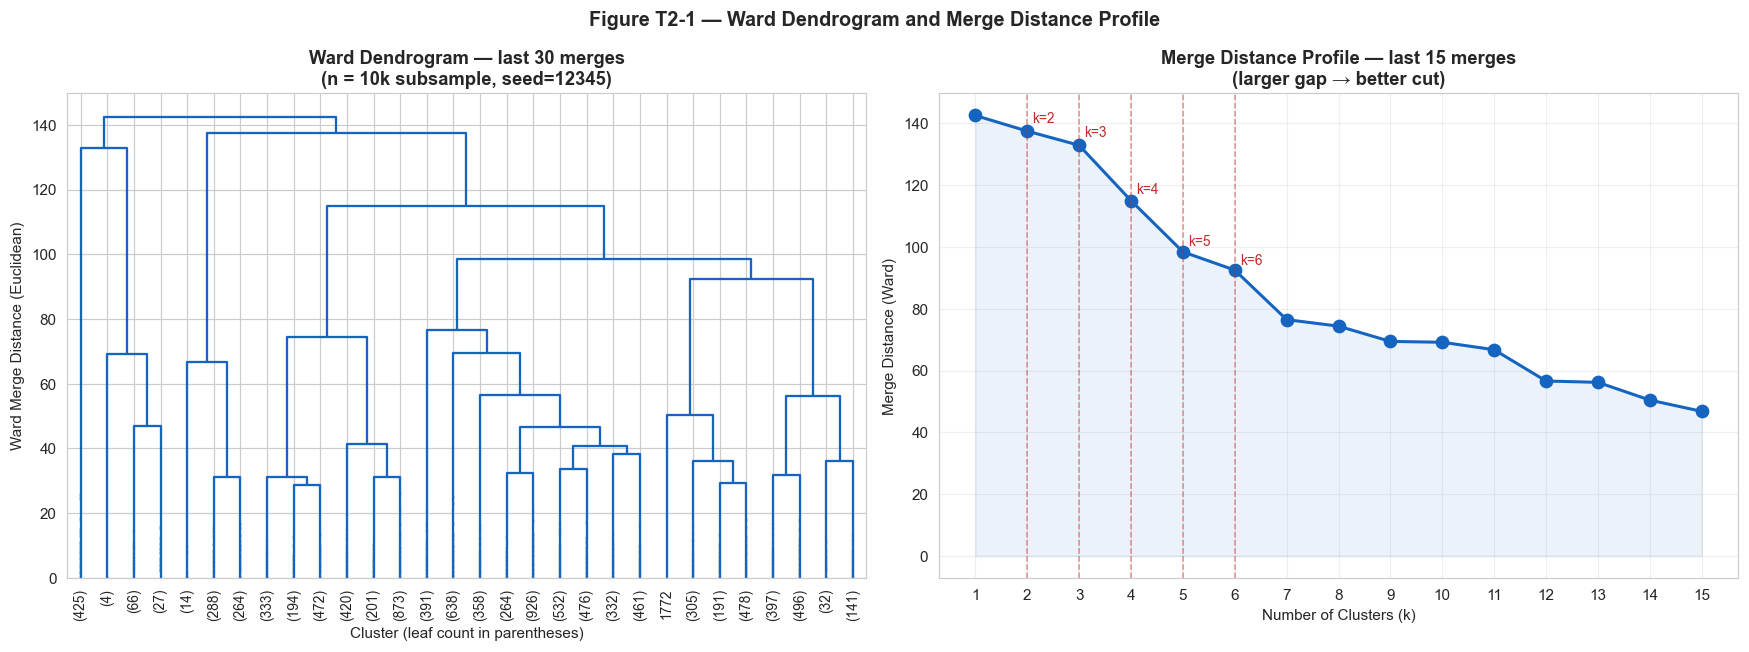

Largest merge distance jumps (largest gap → cut just before):
  k ≈     4: merge distance jump = 17.9102
  k ≈     5: merge distance jump = 16.5751
  k ≈     7: merge distance jump = 16.0295
  k ≈    12: merge distance jump = 10.1316
  k ≈     6: merge distance jump = 5.9096
  k ≈    14: merge distance jump = 5.7492
  k ≈    17: merge distance jump = 5.1341
  k ≈     2: merge distance jump = 5.0524
  k ≈     9: merge distance jump = 4.9474
  k ≈     3: merge distance jump = 4.5905


In [9]:
# Figure T2-1: Dendrogram and merge distance profile
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: truncated dendrogram (last 30 merges)
ax1 = axes[0]
dendrogram(
    Z, ax=ax1,
    truncate_mode='lastp', p=30,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0, above_threshold_color='#1565C0',
)
ax1.set_title('Ward Dendrogram — last 30 merges\n(n = 10k subsample, seed=12345)',
              fontweight='bold')
ax1.set_xlabel('Cluster (leaf count in parentheses)')
ax1.set_ylabel('Ward Merge Distance (Euclidean)')

# Right: merge distance profile — identify the largest jumps
ax2 = axes[1]
last_n = 15
merge_distances = Z[-last_n:, 2][::-1]  # last 'last_n' merges, reversed → index = k
ks_shown = np.arange(1, last_n + 1)

ax2.plot(ks_shown, merge_distances, 'o-', color='#1565C0', linewidth=2, markersize=8)
ax2.fill_between(ks_shown, merge_distances, alpha=0.08, color='#1565C0')

# Annotate the k range we test (2–6)
for k_cut in [2, 3, 4, 5, 6]:
    ax2.axvline(x=k_cut, color='#C62828', linestyle='--', alpha=0.5, linewidth=1)
    ax2.text(k_cut + 0.1, merge_distances[k_cut - 1] * 1.02, f'k={k_cut}',
             color='#C62828', fontsize=9)

ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Merge Distance (Ward)')
ax2.set_title('Merge Distance Profile — last 15 merges\n(larger gap → better cut)',
              fontweight='bold')
ax2.set_xticks(ks_shown)
ax2.grid(True, alpha=0.3)

fig.suptitle('Figure T2-1 — Ward Dendrogram and Merge Distance Profile',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_1_dendrogram.png')
plt.show()

# Print the top merge distance jumps (second derivative guides cut)
print("Largest merge distance jumps (largest gap → cut just before):")
jumps    = np.diff(Z[:, 2])
top_jumps = np.argsort(jumps)[::-1][:10]
for j_idx in top_jumps:
    n_clusters = len(Z) - j_idx
    print(f"  k ≈ {n_clusters:>5d}: merge distance jump = {jumps[j_idx]:.4f}")

**Cut selection rationale:** The merge distance profile guides k selection — the cut is placed just before the largest upward jump, where merging further would sharply increase within-cluster variance. The dendrogram provides confirmatory visual evidence. These observations are then combined with the internal validity indices (Silhouette primary, CH and DB confirmatory) across k ∈ {2, …, 6}.

### 3.3 Ward Hierarchical Clustering — k-Grid Search

In [10]:
# Ward fit on subsample → nearest-centroid propagation to full dataset
#
# Rationale: AgglomerativeClustering requires O(n²) memory. On ~97k rows the full
# linkage matrix would be infeasible. Fixed rule: WARD_N = 10,000 rows, seed = SEED
# (same subsample as the dendrogram → consistent representation).
# Impact is reported in the stability section.

WARD_N  = 10_000   # same as DENDRO_N — declared here for clarity
K_RANGE = range(2, 7)
results_ward = []

X_ward_fit = X_dendro   # shape (WARD_N, n_features)

print(f"Ward fit subsample : {WARD_N:,} rows (seed={SEED}, same as dendrogram)")
print(f"Full dataset size  : {X_R0.shape[0]:,} rows")
print(f"Label propagation  : nearest centroid (Euclidean) on full X_R0")
print()
print(f"{'k':>3} | {'Silhouette':>10} | {'Cal-Har':>12} | {'Davies-B':>10} | {'Time(s)':>8}")
print("-" * 60)

for k in K_RANGE:
    t0 = time.time()

    # Step 1: fit Ward on subsample
    ward = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    sub_labels = ward.fit_predict(X_ward_fit)

    # Step 2: compute centroids from the subsample clusters
    centroids = np.array([
        X_ward_fit[sub_labels == c].mean(axis=0) for c in range(k)
    ])

    # Step 3: assign every full-dataset point to its nearest centroid
    dists_full   = np.linalg.norm(X_R0[:, None, :] - centroids[None, :, :], axis=2)  # (n, k)
    labels_ward  = np.argmin(dists_full, axis=1)

    elapsed = time.time() - t0

    idx = compute_internal_indices(X_R0, labels_ward)
    results_ward.append({
        'k': k, 'time_s': elapsed, 'labels': labels_ward,
        'model': ward, 'centroids': centroids, **idx,
    })
    print(f"{k:>3} | {idx['silhouette']:>10.4f} | {idx['calinski_harabasz']:>12,.0f} "
          f"| {idx['davies_bouldin']:>10.4f} | {elapsed:>8.2f}")

print()
print("Linkage: Ward | Metric: Euclidean")
print("Labels propagated to full dataset via nearest-centroid assignment.")

Ward fit subsample : 10,000 rows (seed=12345, same as dendrogram)
Full dataset size  : 97,750 rows
Label propagation  : nearest centroid (Euclidean) on full X_R0

  k | Silhouette |      Cal-Har |   Davies-B |  Time(s)
------------------------------------------------------------


  2 |     0.4124 |        9,317 |     1.6349 |     2.74


  3 |     0.2871 |        9,655 |     1.4963 |     2.91


  4 |     0.2955 |        9,794 |     1.1616 |     2.70


  5 |     0.1197 |       10,379 |     1.7094 |     2.93


  6 |     0.1232 |       10,302 |     1.8436 |     2.76

Linkage: Ward | Metric: Euclidean
Labels propagated to full dataset via nearest-centroid assignment.


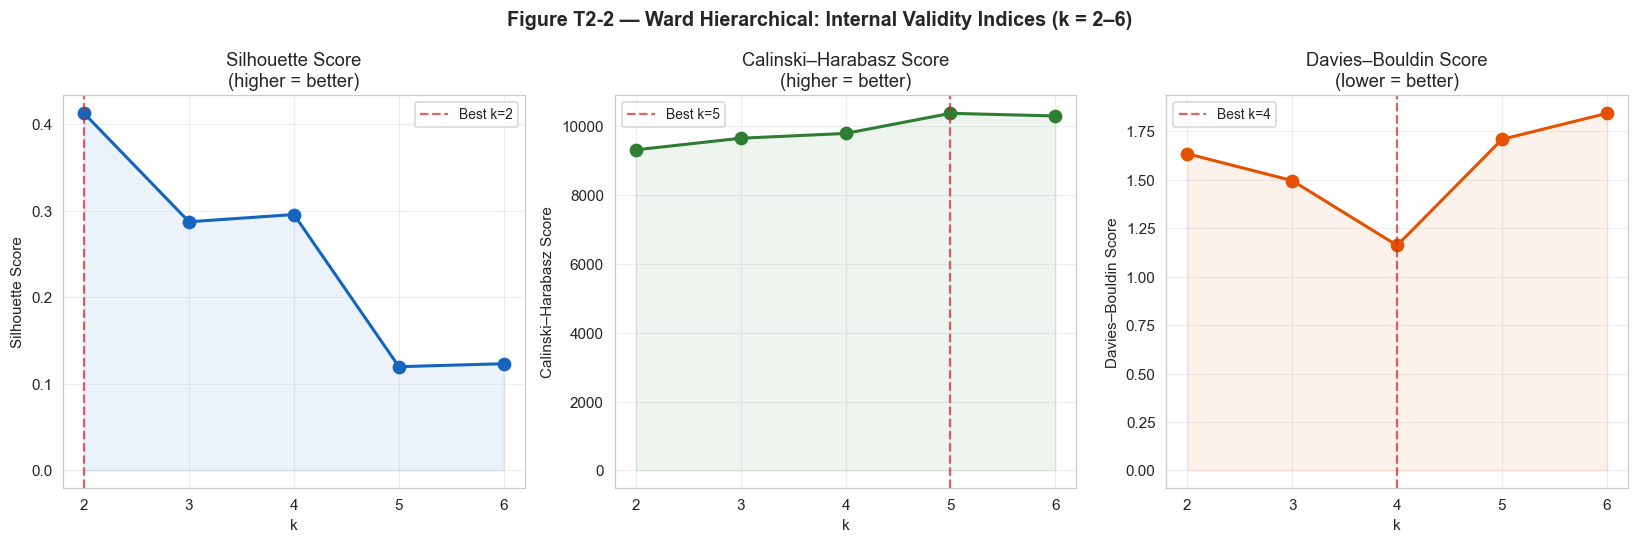

Index-suggested k values:
  Silhouette max        : k = 2
  Calinski–Harabasz max : k = 5
  Davies–Bouldin min    : k = 4


In [11]:
# Figure T2-2: Internal validity indices across k values - Ward
ks_w   = [r['k']                  for r in results_ward]
sils_w = [r['silhouette']          for r in results_ward]
chs_w  = [r['calinski_harabasz']   for r in results_ward]
dbs_w  = [r['davies_bouldin']      for r in results_ward]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (sils_w, 'Silhouette Score',          'higher = better', np.argmax),
    (chs_w,  'Calinski–Harabasz Score',   'higher = better', np.argmax),
    (dbs_w,  'Davies–Bouldin Score',      'lower = better',  np.argmin),
]
colors_p = ['#1565C0', '#2E7D32', '#E65100']

for ax, (vals, ylabel, note, best_fn), col in zip(axes, panels, colors_p):
    ax.plot(ks_w, vals, 'o-', color=col, linewidth=2, markersize=8)
    ax.fill_between(ks_w, vals, alpha=0.08, color=col)
    best_k_p = ks_w[best_fn(vals)]
    ax.axvline(x=best_k_p, color='#C62828', linestyle='--', alpha=0.7,
               label=f'Best k={best_k_p}')
    ax.set_xlabel('k'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}\n({note})')
    ax.set_xticks(ks_w); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Figure T2-2 — Ward Hierarchical: Internal Validity Indices (k = 2–6)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_2_ward_indices.png')
plt.show()

print(f"Index-suggested k values:")
print(f"  Silhouette max        : k = {ks_w[np.argmax(sils_w)]}")
print(f"  Calinski–Harabasz max : k = {ks_w[np.argmax(chs_w)]}")
print(f"  Davies–Bouldin min    : k = {ks_w[np.argmin(dbs_w)]}")

### 3.4 Final k Selection for Ward Hierarchical Clustering

**Selection rule (consistent with Task 1):**
1. Primary criterion: maximise Silhouette Score.
2. Confirmatory: Calinski–Harabasz and Davies–Bouldin should not strongly contradict.
3. Dendrogram gap: the merge distance profile is used as confirmatory structural evidence.
4. Parsimony: among k values within 0.005 of the Silhouette maximum, prefer the smallest k.

The final `BEST_K_WARD` is set below based on the index output above.

In [12]:
# Final k selection
PARSIMONY_GAP  = 0.005
sil_max        = max(sils_w)
candidates     = [k for k, s in zip(ks_w, sils_w) if s >= sil_max - PARSIMONY_GAP]
BEST_K_WARD    = min(candidates)   # parsimony: smallest k within gap

print(f"Silhouette maximum                    : {sil_max:.4f} at k = {ks_w[np.argmax(sils_w)]}")
print(f"Parsimony candidates (±{PARSIMONY_GAP}) : {sorted(candidates)}")
print(f"Selected BEST_K_WARD                  : {BEST_K_WARD}")

best_ward      = next(r for r in results_ward if r['k'] == BEST_K_WARD)
best_ward_labels = best_ward['labels']

# Attach cluster labels to the working dataframe
df_ward = df.copy()
df_ward['cluster_ward'] = best_ward_labels

print(f"\nCluster size distribution (Ward, k={BEST_K_WARD}):")
for c, cnt in pd.Series(best_ward_labels).value_counts().sort_index().items():
    print(f"  Cluster {c}: {cnt:>8,}  ({cnt/len(best_ward_labels)*100:.1f}%)")

print(f"\nValidation metrics at k={BEST_K_WARD}:")
print(f"  Silhouette        : {best_ward['silhouette']:.4f}")
print(f"  Calinski–Harabasz : {best_ward['calinski_harabasz']:.0f}")
print(f"  Davies–Bouldin    : {best_ward['davies_bouldin']:.4f}")

Silhouette maximum                    : 0.4124 at k = 2
Parsimony candidates (±0.005) : [2]
Selected BEST_K_WARD                  : 2

Cluster size distribution (Ward, k=2):
  Cluster 0:   92,575  (94.7%)
  Cluster 1:    5,175  (5.3%)

Validation metrics at k=2:
  Silhouette        : 0.4124
  Calinski–Harabasz : 9317
  Davies–Bouldin    : 1.6349


## 4. Task 2.2 - Evaluation: Baseline (K-Means) vs Ward Hierarchical

Both methods are evaluated using the **same evaluation protocol**: Silhouette (primary, subsampled to `SUBSAMPLE_N=10,000`), Calinski–Harabasz, and Davies–Bouldin, all computed on the same `X_R0` matrix with Euclidean distance.

In [13]:
# Re-run K-Means on X_R0 for comparison (mirrors Task 1 parameters)
# Task 1 used: init='k-means++', n_init=5, max_iter=300, random_state=SEED
K_RANGE_LIST = list(K_RANGE)
results_km_full = []

print(f"{'k':>3} | {'Silhouette':>10} | {'Cal-Har':>12} | {'Davies-B':>10} | {'Time(s)':>8}")
print("-" * 60)

for k in K_RANGE_LIST:
    t0  = time.time()
    km  = KMeans(n_clusters=k, init='k-means++', n_init=5, max_iter=300,
                 random_state=SEED)
    lbl = km.fit_predict(X_R0)
    elapsed = time.time() - t0
    idx = compute_internal_indices(X_R0, lbl)
    results_km_full.append({'k': k, 'labels': lbl, 'time_s': elapsed, **idx})
    print(f"{k:>3} | {idx['silhouette']:>10.4f} | {idx['calinski_harabasz']:>12,.0f} "
          f"| {idx['davies_bouldin']:>10.4f} | {elapsed:>8.2f}")

  k | Silhouette |      Cal-Har |   Davies-B |  Time(s)
------------------------------------------------------------


  2 |     0.1008 |        9,835 |     2.8723 |     0.36


  3 |     0.1185 |       10,265 |     2.2247 |     0.32


  4 |     0.1227 |       10,223 |     1.8511 |     0.46


  5 |     0.1141 |       10,025 |     1.9073 |     0.44


  6 |     0.1293 |       10,573 |     1.7424 |     0.47


In [14]:
# Point comparison at BEST_K_WARD
# K-Means best k (mirrors Task 1 selection rule)
sils_km = [r['silhouette'] for r in results_km_full]
sil_km_max = max(sils_km)
candidates_km = [r['k'] for r in results_km_full if r['silhouette'] >= sil_km_max - PARSIMONY_GAP]
BEST_K_KM = min(candidates_km)
best_km   = next(r for r in results_km_full if r['k'] == BEST_K_KM)
km_labels = best_km['labels']

print("Point comparison — best k per method")
print("=" * 70)
print(f"{'Method':<35} {'k':>3} | {'Silhouette':>10} | {'Cal-Har':>12} | {'Davies-B':>10}")
print("-" * 70)
print(f"{'K-Means (k-means++, n_init=5)':<35} {BEST_K_KM:>3} | "
      f"{best_km['silhouette']:>10.4f} | {best_km['calinski_harabasz']:>12,.0f} | "
      f"{best_km['davies_bouldin']:>10.4f}")
print(f"{'Ward Hierarchical':<35} {BEST_K_WARD:>3} | "
      f"{best_ward['silhouette']:>10.4f} | {best_ward['calinski_harabasz']:>12,.0f} | "
      f"{best_ward['davies_bouldin']:>10.4f}")
print("=" * 70)
print("Note: higher Silhouette / CH = better; lower Davies–Bouldin = better.")
print("All metrics computed in Euclidean space — consistent with both methods.")

Point comparison — best k per method
Method                                k | Silhouette |      Cal-Har |   Davies-B
----------------------------------------------------------------------
K-Means (k-means++, n_init=5)         6 |     0.1293 |       10,573 |     1.7424
Ward Hierarchical                     2 |     0.4124 |        9,317 |     1.6349
Note: higher Silhouette / CH = better; lower Davies–Bouldin = better.
All metrics computed in Euclidean space — consistent with both methods.


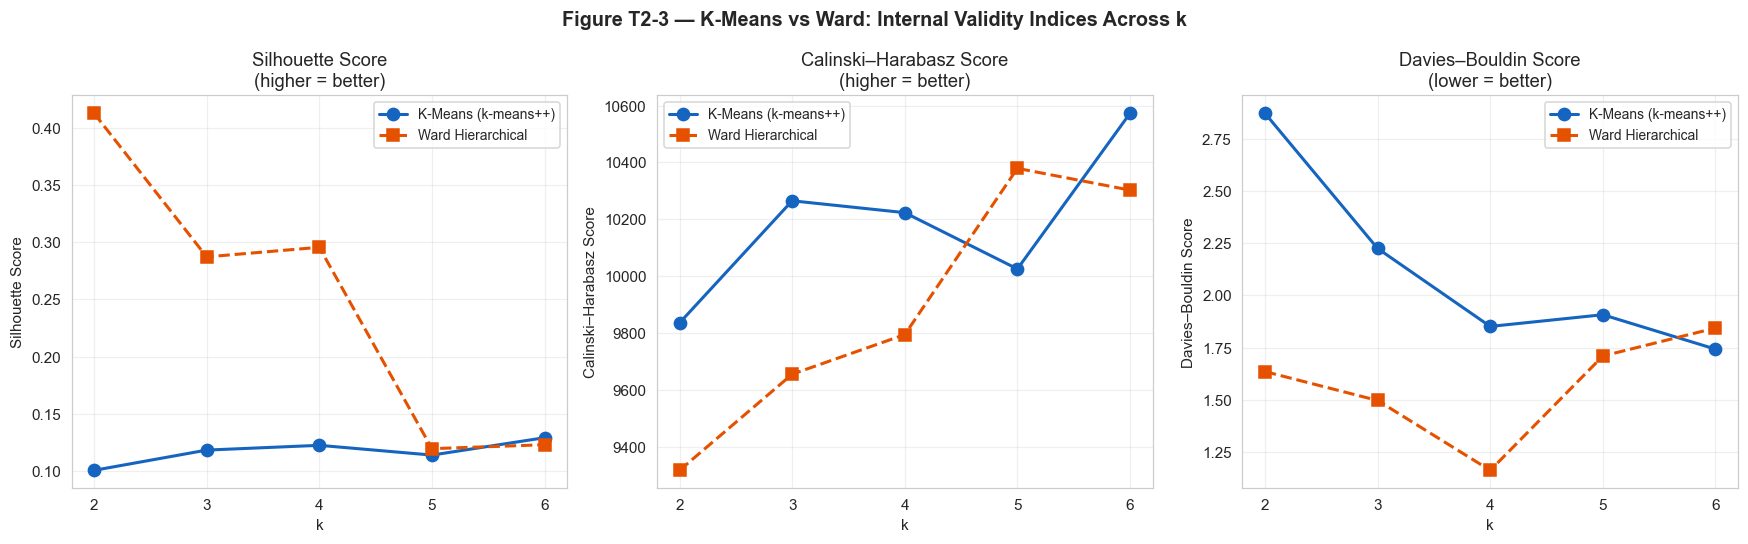

In [15]:
# Figure T2-3: K-Means vs Ward — indices across all k
sils_km_all = [r['silhouette']        for r in results_km_full]
chs_km_all  = [r['calinski_harabasz'] for r in results_km_full]
dbs_km_all  = [r['davies_bouldin']    for r in results_km_full]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panel_data = [
    (sils_km_all, sils_w, 'Silhouette Score',        'higher = better'),
    (chs_km_all,  chs_w,  'Calinski–Harabasz Score', 'higher = better'),
    (dbs_km_all,  dbs_w,  'Davies–Bouldin Score',    'lower = better'),
]

for ax, (km_v, wd_v, ylabel, note) in zip(axes, panel_data):
    ax.plot(K_RANGE_LIST, km_v, 'o-', label='K-Means (k-means++)',
            color='#1565C0', linewidth=2, markersize=8)
    ax.plot(K_RANGE_LIST, wd_v, 's--', label='Ward Hierarchical',
            color='#E65100', linewidth=2, markersize=8)
    ax.set_xlabel('k'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}\n({note})')
    ax.set_xticks(K_RANGE_LIST)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Figure T2-3 — K-Means vs Ward: Internal Validity Indices Across k',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_3_kmeans_vs_ward_indices.png')
plt.show()

## 5. Stability and Sensitivity Analysis

Ward hierarchical clustering with fixed linkage and distance is **fully deterministic** — the same input always produces the same output. Therefore, following the assignment requirement, "random seeds" are replaced by **controlled resampling / perturbation**: 5 bootstrap-style resamples (90% of data, without replacement) using pre-declared seeds. ARI across resample pairs measures label consistency.

Additionally, one controlled preprocessing variant (**RobustScaler** vs StandardScaler for the numerical block) assesses sensitivity to scaling choice.

In [16]:
# Stability: 5 bootstrap resamples (90%, without replacement)
N_RESAMPLES     = 10
RESAMPLE_FRAC   = 0.90
RESAMPLE_SEEDS  = [10, 42, 77, 123, 999, 321, 654, 1010, 2026, 31415]   # declared up-front, logged in experiments.csv

resample_results    = []
all_resample_labels = []   # (idx_array, labels_array)

print(f"Protocol : {N_RESAMPLES} resamples, {RESAMPLE_FRAC*100:.0f}% of data (without replacement)")
print(f"Ward fit : up to {WARD_N:,} rows per resample | k = {BEST_K_WARD}")
print()
print(f"{'Seed':>5} | {'n_resample':>10} | {'Silhouette':>10} | {'Cal-Har':>12} | "
      f"{'Davies-B':>10} | {'Time(s)':>8}")
print("-" * 75)

for seed_i in RESAMPLE_SEEDS:
    rng_r  = np.random.default_rng(seed_i)
    n_r    = int(X_R0.shape[0] * RESAMPLE_FRAC)
    idx_r  = rng_r.choice(X_R0.shape[0], size=n_r, replace=False)
    X_r    = X_R0[idx_r]

    # Ward fit on at most WARD_N rows of this resample
    fit_n  = min(WARD_N, len(X_r))
    idx_fit = rng_r.choice(len(X_r), size=fit_n, replace=False)
    X_fit_r = X_r[idx_fit]

    t0 = time.time()
    ward_r    = AgglomerativeClustering(n_clusters=BEST_K_WARD,
                                        linkage='ward', metric='euclidean')
    sub_lab_r = ward_r.fit_predict(X_fit_r)
    centroids_r = np.array([
        X_fit_r[sub_lab_r == c].mean(axis=0) for c in range(BEST_K_WARD)
    ])
    dists_r  = np.linalg.norm(X_r[:, None, :] - centroids_r[None, :, :], axis=2)
    labels_r = np.argmin(dists_r, axis=1)
    elapsed  = time.time() - t0

    idx = compute_internal_indices(X_r, labels_r)
    resample_results.append({
        'seed': seed_i, 'n': n_r, 'time_s': elapsed, **idx,
    })
    all_resample_labels.append((idx_r, labels_r))

    print(f"{seed_i:>5} | {n_r:>10,} | {idx['silhouette']:>10.4f} | "
          f"{idx['calinski_harabasz']:>12,.0f} | {idx['davies_bouldin']:>10.4f} | "
          f"{elapsed:>8.2f}")

sil_res = [r['silhouette']        for r in resample_results]
ch_res  = [r['calinski_harabasz'] for r in resample_results]
db_res  = [r['davies_bouldin']    for r in resample_results]

print()
print("Summary (mean ± std across 5 resamples):")
print(f"  Silhouette        : {np.mean(sil_res):.4f} ± {np.std(sil_res):.4f}")
print(f"  Calinski–Harabasz : {np.mean(ch_res):.0f} ± {np.std(ch_res):.0f}")
print(f"  Davies–Bouldin    : {np.mean(db_res):.4f} ± {np.std(db_res):.4f}")

Protocol : 10 resamples, 90% of data (without replacement)
Ward fit : up to 10,000 rows per resample | k = 2

 Seed | n_resample | Silhouette |      Cal-Har |   Davies-B |  Time(s)
---------------------------------------------------------------------------


   10 |     87,975 |     0.3994 |        8,391 |     1.6323 |     2.92


   42 |     87,975 |     0.4116 |        8,445 |     1.5919 |     2.73


   77 |     87,975 |     0.3550 |        8,519 |     1.2693 |     2.47


  123 |     87,975 |     0.3948 |        8,534 |     1.5616 |     2.61


...

  321 |     87,975 |     0.3869 |        8,349 |     1.6348 |     2.20


  654 |     87,975 |     0.3536 |        8,571 |     1.2624 |     2.20


 1010 |     87,975 |     0.4091 |        8,442 |     1.6035 |     2.16


 2026 |     87,975 |     0.4046 |        8,364 |     1.6300 |     2.17


31415 |     87,975 |     0.3557 |        8,543 |     1.2724 |     2.14

Summary (mean ± std across 5 resamples):
  Silhouette        : 0.3862 ± 0.0218
  Calinski–Harabasz : 8453 ± 79
  Davies–Bouldin    : 1.5062 ± 0.1573


In [17]:
# Pairwise ARI between resamples (on overlapping indices)
ari_matrix = np.full((N_RESAMPLES, N_RESAMPLES), np.nan)
ari_values = []

for (i, (idx_i, lab_i)), (j, (idx_j, lab_j)) in combinations(enumerate(all_resample_labels), 2):
    common = np.intersect1d(idx_i, idx_j)
    if len(common) < 100:
        continue
    # Map common indices back to positions in each resample
    sort_i = np.argsort(idx_i);  sorted_idx_i = idx_i[sort_i]
    sort_j = np.argsort(idx_j);  sorted_idx_j = idx_j[sort_j]
    in_i   = np.isin(sorted_idx_i, common)
    in_j   = np.isin(sorted_idx_j, common)
    lab_ic = lab_i[sort_i][in_i]
    lab_jc = lab_j[sort_j][in_j]

    if len(lab_ic) == len(lab_jc) > 0:
        ari_val = adjusted_rand_score(lab_ic, lab_jc)
        ari_matrix[i, j] = ari_val
        ari_matrix[j, i] = ari_val
        ari_values.append(ari_val)

np.fill_diagonal(ari_matrix, 1.0)

print("Pairwise ARI between resamples (on overlapping observations):")
print(
    pd.DataFrame(
        ari_matrix,
        index=[f'Run {s}' for s in RESAMPLE_SEEDS],
        columns=[f'Run {s}' for s in RESAMPLE_SEEDS],
    ).round(3).to_string()
)
print()
if ari_values:
    mean_ari = np.mean(ari_values)
    std_ari  = np.std(ari_values)
    print(f"Mean pairwise ARI : {mean_ari:.4f} ± {std_ari:.4f}")
    if mean_ari > 0.8:
        print("Interpretation: High ARI (> 0.8) — the Ward partition is highly stable "
              "under 90% resampling perturbation.")
    elif mean_ari > 0.6:
        print("Interpretation: Moderate ARI (0.6–0.8) — core structure is preserved; "
              "some boundary sensitivity.")
    else:
        print("Interpretation: Low ARI (< 0.6) — conclusions are sensitive to the "
              "subsample; interpret with caution.")

Pairwise ARI between resamples (on overlapping observations):
           Run 10  Run 42  Run 77  Run 123  Run 999  Run 321  Run 654  Run 1010  Run 2026  Run 31415
Run 10      1.000   0.989   0.917    0.984    0.994    0.998    0.919     0.995     0.999      0.920
Run 42      0.989   1.000   0.929    0.995    0.994    0.986    0.930     0.993     0.988      0.930
Run 77      0.917   0.929   1.000    0.938    0.924    0.916    0.999     0.925     0.918      1.000
Run 123     0.984   0.995   0.938    1.000    0.990    0.980    0.939     0.988     0.983      0.939
Run 999     0.994   0.994   0.924    0.990    1.000    0.990    0.926     0.998     0.993      0.927
Run 321     0.998   0.986   0.916    0.980    0.990    1.000    0.918     0.993     0.997      0.919
Run 654     0.919   0.930   0.999    0.939    0.926    0.918    1.000     0.926     0.920      0.999
Run 1010    0.995   0.993   0.925    0.988    0.998    0.993    0.926     1.000     0.995      0.927
Run 2026    0.999   0.988   0

In [18]:
# Controlled preprocessing variant: RobustScaler
# Identical to the R1 sensitivity variant declared in Task 1.
# Only the numerical scaler changes; categorical encoding is unchanged.

numeric_log_robust = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler',  RobustScaler()),
])
numeric_lin_robust = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
])

preprocessor_R1 = ColumnTransformer(
    transformers=[
        ('num_log', numeric_log_robust, NUM_FEATURES_LOG),
        ('num_lin', numeric_lin_robust, NUM_FEATURES_LIN),
        ('num_bin', numeric_bin_pipe,   NUM_FEATURES_BIN),
        ('cat',     cat_pipe,           CAT_FEATURES),
    ],
    remainder='drop',
)
X_R1 = preprocessor_R1.fit_transform(df)
print(f"RobustScaler representation (R1) shape: {X_R1.shape}")

# Ward on R1 — same subsampling rule as main fit
ward_r1    = AgglomerativeClustering(n_clusters=BEST_K_WARD, linkage='ward', metric='euclidean')
X_r1_fit   = X_R1[idx_dendro]   # same WARD_N subsample index as R0
sub_lab_r1 = ward_r1.fit_predict(X_r1_fit)
cents_r1   = np.array([X_r1_fit[sub_lab_r1 == c].mean(axis=0) for c in range(BEST_K_WARD)])
dists_r1   = np.linalg.norm(X_R1[:, None, :] - cents_r1[None, :, :], axis=2)
labels_r1  = np.argmin(dists_r1, axis=1)

idx_r1     = compute_internal_indices(X_R1, labels_r1)
idx_r0     = compute_internal_indices(X_R0, best_ward_labels)  # baseline
ari_scaler = adjusted_rand_score(best_ward_labels, labels_r1)

print()
print(f"Preprocessing sensitivity (Ward, k={BEST_K_WARD}):")
print("=" * 70)
print(f"{'Scaler':<22} | {'Silhouette':>10} | {'Cal-Har':>12} | {'Davies-B':>10}")
print("-" * 70)
print(f"{'StandardScaler (R0)':<22} | {idx_r0['silhouette']:>10.4f} | "
      f"{idx_r0['calinski_harabasz']:>12,.0f} | {idx_r0['davies_bouldin']:>10.4f}")
print(f"{'RobustScaler (R1)':<22} | {idx_r1['silhouette']:>10.4f} | "
      f"{idx_r1['calinski_harabasz']:>12,.0f} | {idx_r1['davies_bouldin']:>10.4f}")
print("=" * 70)
print(f"ARI (StandardScaler vs RobustScaler): {ari_scaler:.4f}")
if ari_scaler > 0.8:
    print("Interpretation: High ARI — conclusions are robust to the scaling choice.")
elif ari_scaler > 0.6:
    print("Interpretation: Moderate ARI — scaling has some effect; core structure preserved.")
else:
    print("Interpretation: Low ARI — conclusions are sensitive to scaling; discuss implications.")

RobustScaler representation (R1) shape: (97750, 57)



Preprocessing sensitivity (Ward, k=2):
Scaler                 | Silhouette |      Cal-Har |   Davies-B
----------------------------------------------------------------------
StandardScaler (R0)    |     0.4124 |        9,317 |     1.6349
RobustScaler (R1)      |     0.1869 |       14,184 |     1.9212
ARI (StandardScaler vs RobustScaler): -0.0020
Interpretation: Low ARI — conclusions are sensitive to scaling; discuss implications.


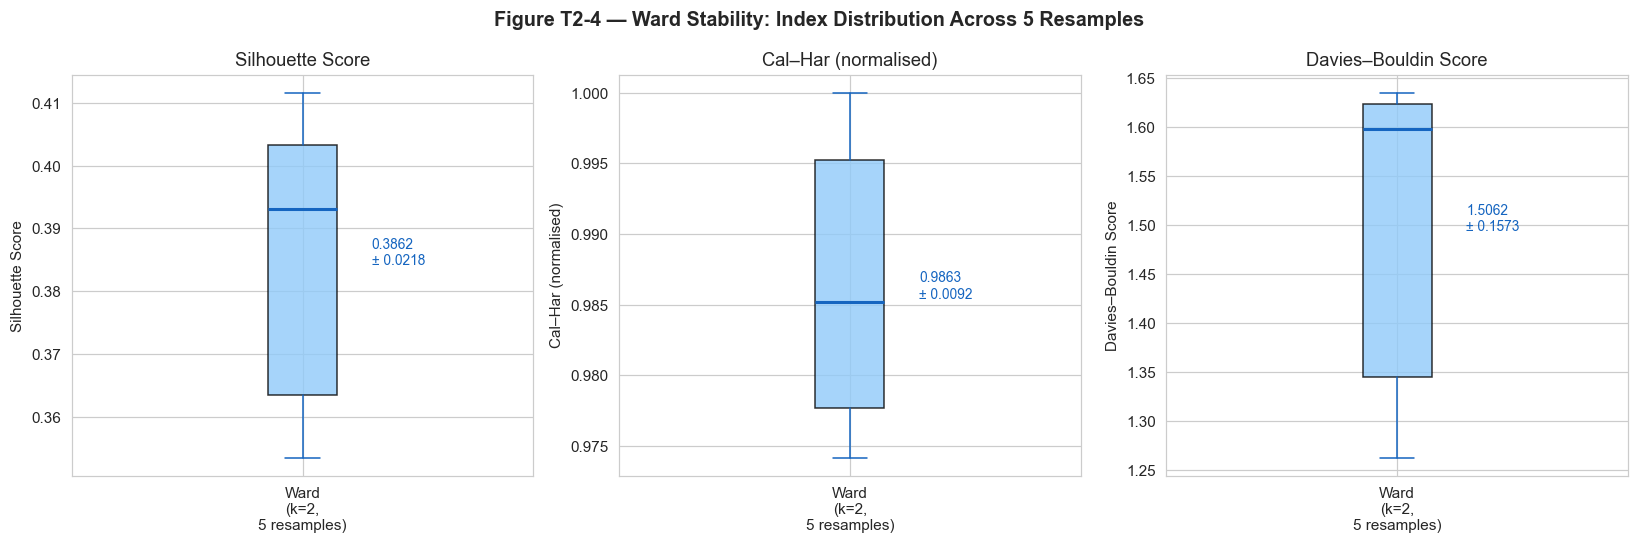

In [19]:
# Figure T2-4: Stability summary — index distribution across 5 resamples
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ch_norm_res = [v / max(ch_res) if max(ch_res) > 0 else v for v in ch_res]

for ax, (vals, ylabel) in zip(
    axes,
    [(sil_res, 'Silhouette Score'),
     (ch_norm_res, 'Cal–Har (normalised)'),
     (db_res, 'Davies–Bouldin Score')],
):
    ax.boxplot(vals, patch_artist=True,
               boxprops=dict(facecolor='#90CAF9', alpha=0.8),
               medianprops=dict(color='#1565C0', linewidth=2),
               whiskerprops=dict(color='#1565C0'),
               capprops=dict(color='#1565C0'))
    ax.set_xticklabels([f'Ward\n(k={BEST_K_WARD},\n5 resamples)'])
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split('\n')[0])
    ax.text(1.15, np.mean(vals),
            f'{np.mean(vals):.4f}\n± {np.std(vals):.4f}',
            ha='left', va='center', fontsize=9, color='#1565C0')

fig.suptitle('Figure T2-4 — Ward Stability: Index Distribution Across 5 Resamples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_4_ward_stability.png')
plt.show()

## 6. Cluster Profiles and Interpretation (Ward)

Cluster profiles are provided in three forms:
1. **Numerical profiles**: mean / median / std of each clustering input, by cluster.
2. **Categorical profiles**: dominant category (mode) of each clustering input, by cluster.
3. **Post-hoc profiles**: `is_canceled`, `booking_changes`, and `adr` by cluster. These variables were **NOT** clustering inputs (leakage control, Corrections #2 and #3); they are used here only to interpret and validate the discovered segments.

In [20]:
# Numerical cluster profiles
profile_num_ward = (
    df_ward.groupby('cluster_ward')[ALL_NUM]
    .agg(['mean', 'median', 'std'])
    .round(3)
)
print(f"WARD CLUSTER PROFILES — Numerical inputs (k={BEST_K_WARD})")
print("=" * 90)
print(profile_num_ward.to_string())
profile_num_ward.to_csv(TBL_DIR / 'ward_profile_numerical.csv')

WARD CLUSTER PROFILES — Numerical inputs (k=2)
             lead_time                 previous_cancellations               previous_bookings_not_canceled               total_nights               weekend_share               party_size               required_car_parking_spaces               total_of_special_requests               is_repeated_guest              
                  mean median      std                   mean median    std                           mean median    std         mean median    std          mean median    std       mean median    std                        mean median    std                      mean median    std              mean median    std
cluster_ward                                                                                                                                                                                                                                                                                                              
0       

In [21]:
# Categorical cluster profiles (modal value per cluster)
print(f"WARD CLUSTER PROFILES — Categorical inputs (dominant category)")
print("=" * 70)
modes_ward = {}
for feat in CAT_FEATURES:
    m = df_ward.groupby('cluster_ward')[feat].agg(
        lambda s: s.value_counts().index[0]
    )
    modes_ward[feat] = m
    print(f"  {feat:25s}: {dict(m)}")
pd.DataFrame(modes_ward).to_csv(TBL_DIR / 'ward_profile_categorical.csv')

WARD CLUSTER PROFILES — Categorical inputs (dominant category)
  market_segment           : {0: 'Online TA', 1: 'Online TA'}
  reserved_room_type       : {0: 'A', 1: 'A'}
  meal                     : {0: 'BB', 1: 'BB'}
  customer_type            : {0: 'Transient', 1: 'Transient'}
  deposit_type             : {0: 'No Deposit', 1: 'No Deposit'}
  country                  : {0: 'PRT', 1: 'PRT'}
  arrival_date_month       : {0: 'August', 1: 'August'}


In [22]:
# Post-hoc profiling — attach profiling-only variables (NOT used as inputs)
df_ward['is_canceled']     = df['is_canceled'].values
df_ward['hotel']           = df['hotel'].values
df_ward['booking_changes'] = df['booking_changes'].values
df_ward['adr']             = df['adr'].values

posthoc_ward = df_ward.groupby('cluster_ward').agg(
    cluster_size         = ('is_canceled', 'count'),
    cancellation_rate_pct= ('is_canceled', lambda s: s.mean() * 100),
    mean_booking_changes = ('booking_changes', 'mean'),
    mean_adr             = ('adr', lambda s: s[s > 0].mean()),
    median_adr           = ('adr', lambda s: s[s > 0].median()),
).round(3)

print("POST-HOC PROFILING — outcome / profiling-only variables by cluster")
print("=" * 80)
print(posthoc_ward.to_string())
posthoc_ward.to_csv(TBL_DIR / 'ward_profile_posthoc.csv')

POST-HOC PROFILING — outcome / profiling-only variables by cluster
              cluster_size  cancellation_rate_pct  mean_booking_changes  mean_adr  median_adr
cluster_ward                                                                                 
0                    92575                 43.330                 0.178   103.920      96.000
1                     5175                  0.444                 0.290   111.523     100.485


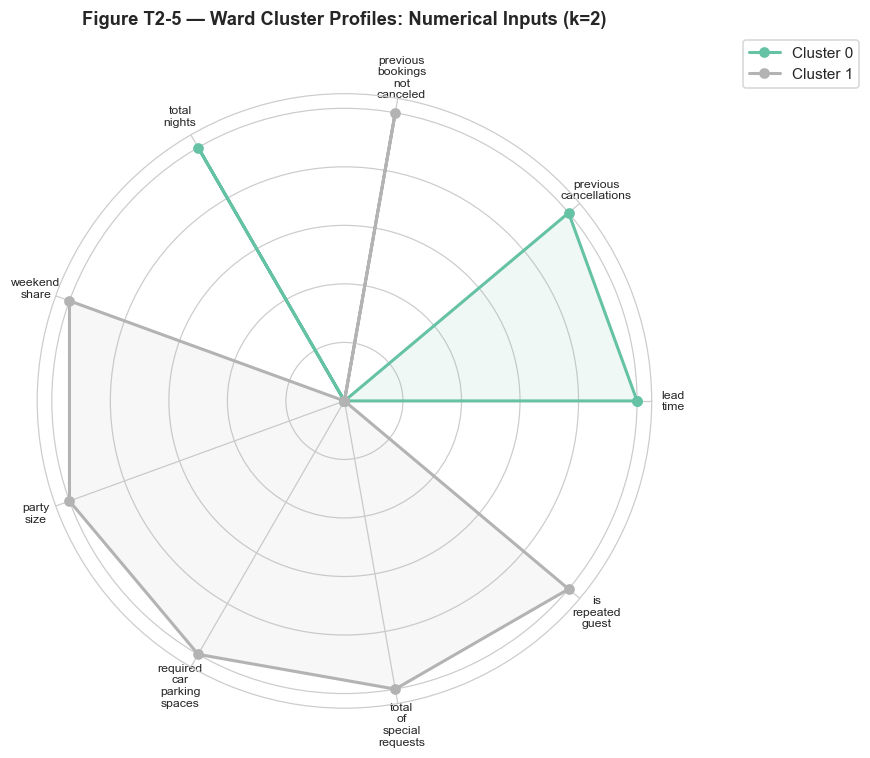

In [23]:
# Figure T2-5: Radar chart — Ward cluster profiles (numerical inputs, normalised)
profile_means_ward = df_ward.groupby('cluster_ward')[ALL_NUM].mean()
profile_norm_ward  = (
    (profile_means_ward - profile_means_ward.min())
    / (profile_means_ward.max() - profile_means_ward.min() + 1e-9)
)

categories = ALL_NUM
N_cats     = len(categories)
angles     = np.linspace(0, 2 * np.pi, N_cats, endpoint=False).tolist()
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
colors  = plt.cm.Set2(np.linspace(0, 1, BEST_K_WARD))

for c in range(BEST_K_WARD):
    values  = profile_norm_ward.loc[c].tolist() + [profile_norm_ward.loc[c].tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {c}', color=colors[c])
    ax.fill(angles, values, alpha=0.10, color=colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in categories], size=8)
ax.set_yticklabels([])
ax.set_title(f'Figure T2-5 — Ward Cluster Profiles: Numerical Inputs (k={BEST_K_WARD})',
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10))

plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_5_ward_radar.png')
plt.show()

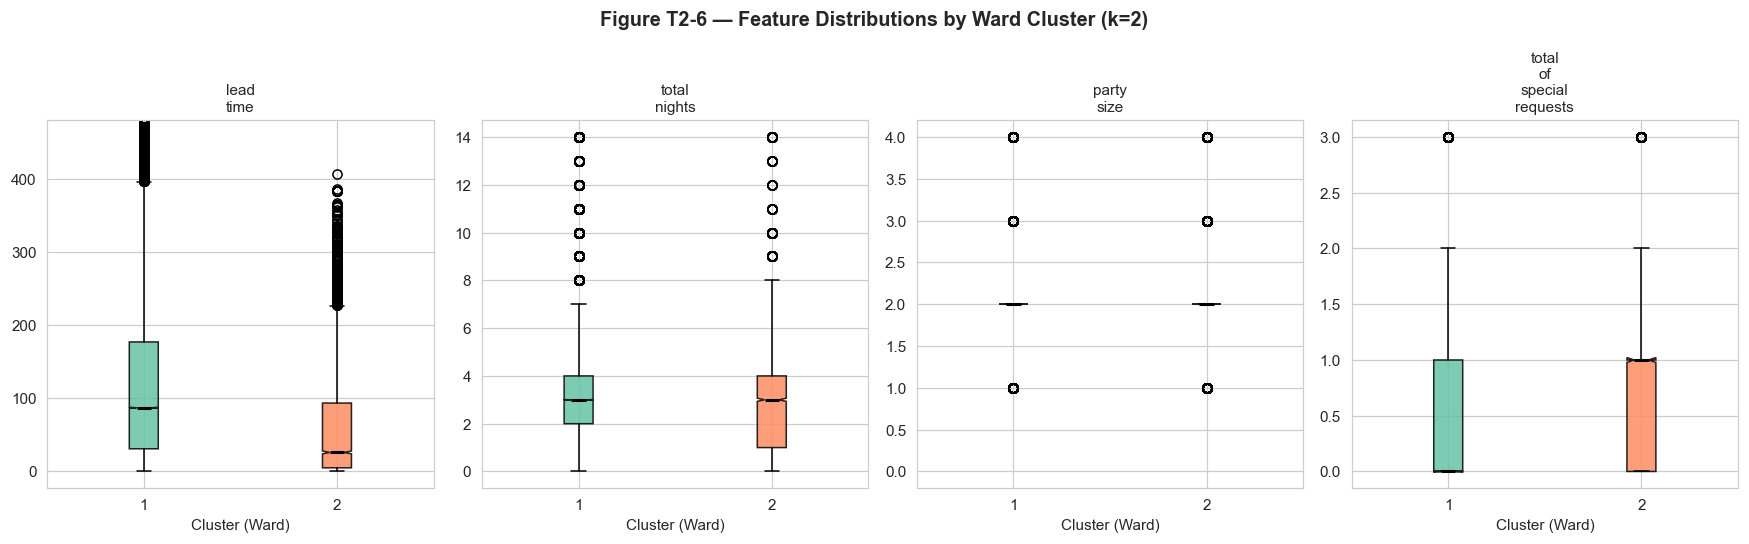

In [24]:
# Figure T2-6: Box plots of key numerical features by Ward cluster
KEY_FEATS = ['lead_time', 'total_nights', 'party_size', 'total_of_special_requests']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = sns.color_palette('Set2', BEST_K_WARD)

for i, feat in enumerate(KEY_FEATS):
    data = [df_ward[df_ward['cluster_ward'] == c][feat].dropna() for c in range(BEST_K_WARD)]
    bp   = axes[i].boxplot(data, patch_artist=True, notch=True,
                            boxprops=dict(alpha=0.85),
                            medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[i].set_title(feat.replace('_', '\n'), fontsize=10)
    axes[i].set_xlabel('Cluster (Ward)')
    p99 = df_ward[feat].quantile(0.99)
    axes[i].set_ylim(-(p99 * 0.05), p99 * 1.05)

fig.suptitle(f'Figure T2-6 — Feature Distributions by Ward Cluster (k={BEST_K_WARD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_6_ward_boxplots.png')
plt.show()

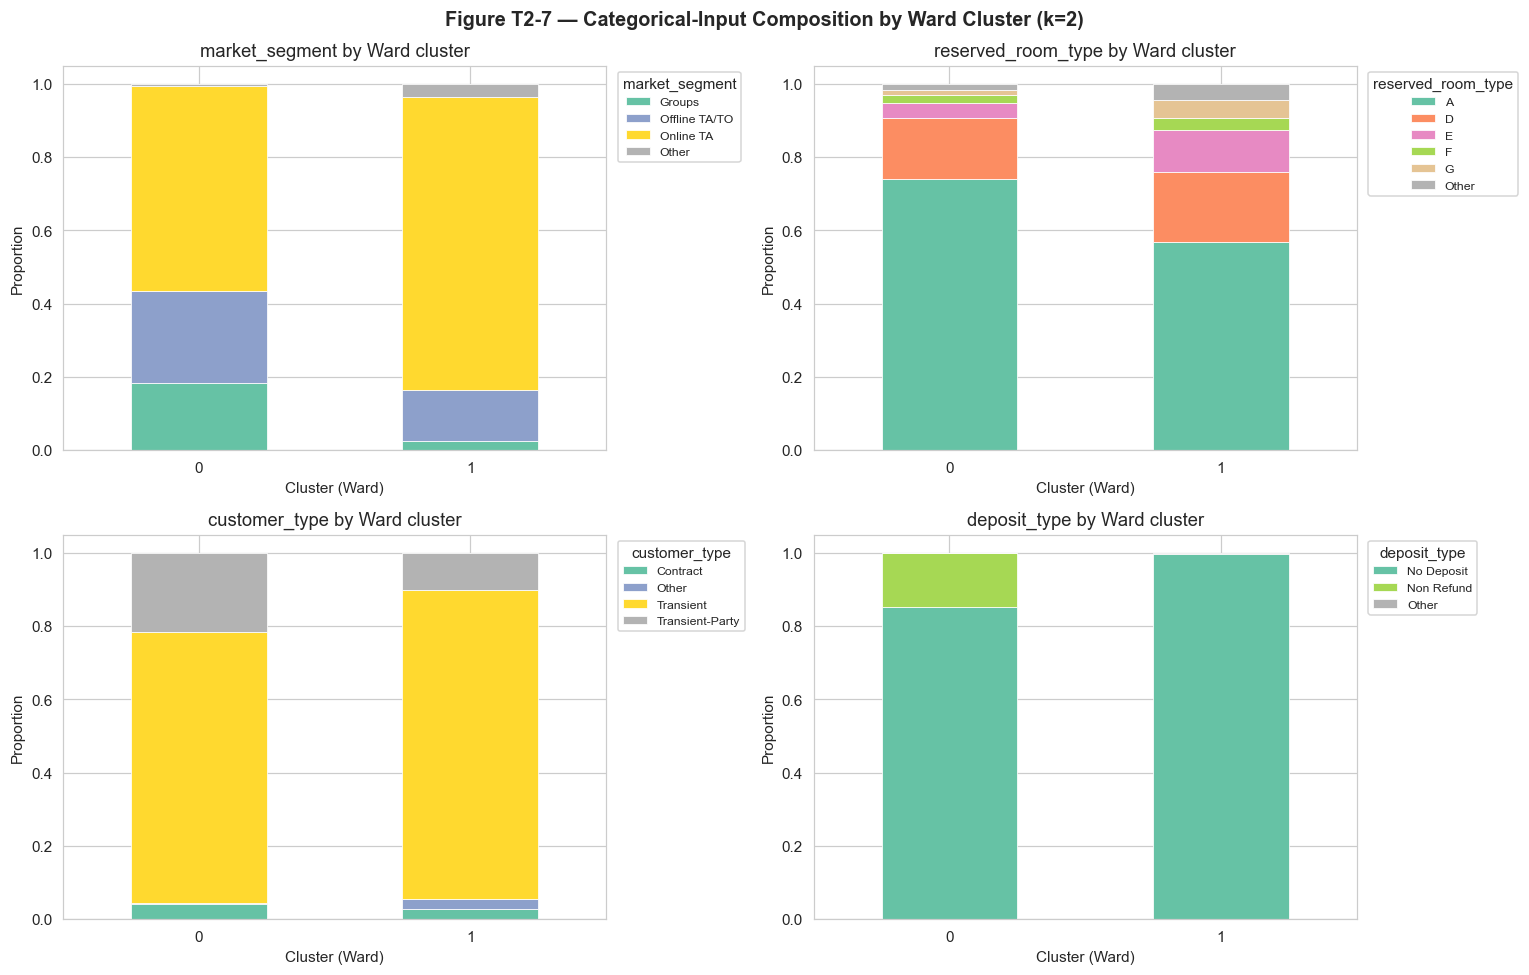

In [25]:
# Figure T2-7: Categorical composition by Ward cluster
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(['market_segment', 'reserved_room_type',
                           'customer_type', 'deposit_type']):
    cross = pd.crosstab(df_ward['cluster_ward'], df_ward[feat], normalize='index')
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               colormap='Set2', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{feat} by Ward cluster')
    axes[i].set_xlabel('Cluster (Ward)'); axes[i].set_ylabel('Proportion')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=feat, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle(f'Figure T2-7 — Categorical-Input Composition by Ward Cluster (k={BEST_K_WARD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_7_ward_cat.png')
plt.show()

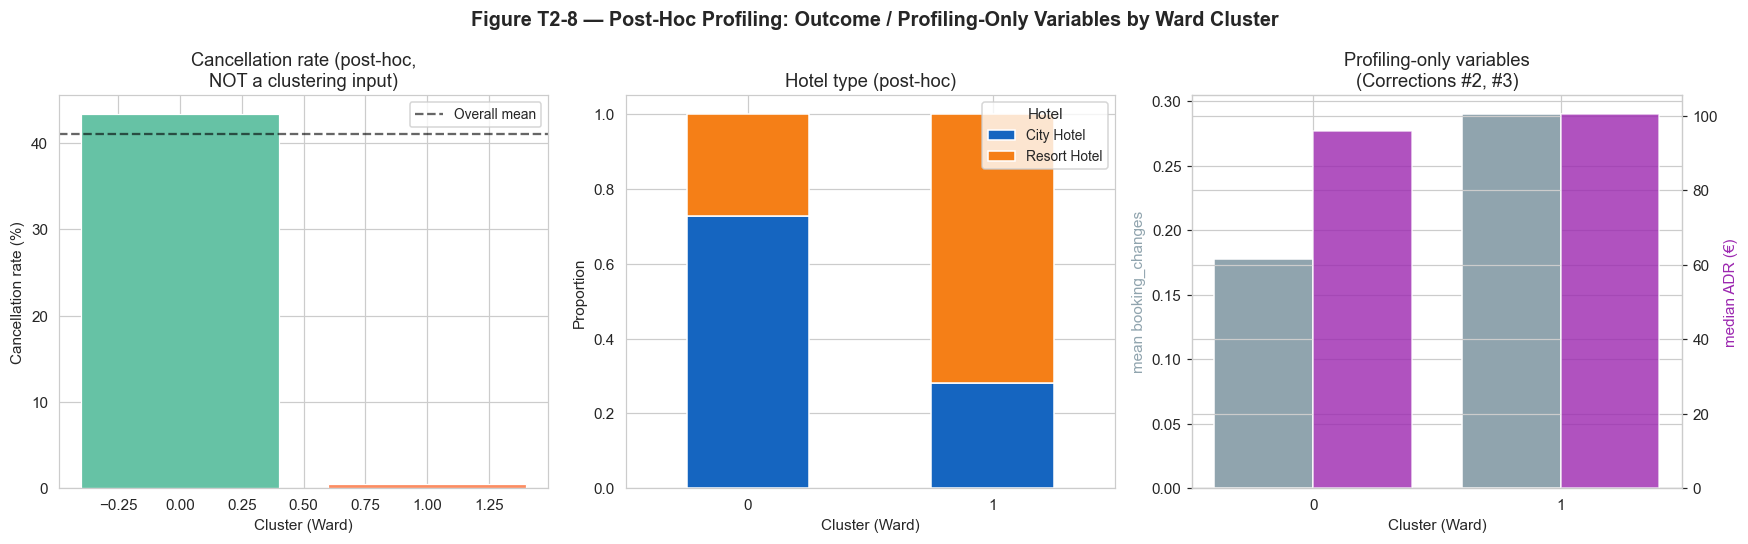

In [26]:
# Figure T2-8: Post-hoc profiling - cancellation rate, hotel type, ADR
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_c = sns.color_palette('Set2', BEST_K_WARD)

# 1) Cancellation rate
cancel_rates = df_ward.groupby('cluster_ward')['is_canceled'].mean().mul(100)
axes[0].bar(cancel_rates.index, cancel_rates.values,
            color=colors_c, edgecolor='white', linewidth=0.8)
axes[0].axhline(df_ward['is_canceled'].mean() * 100, color='black',
                linestyle='--', alpha=0.6, label='Overall mean')
axes[0].set_xlabel('Cluster (Ward)'); axes[0].set_ylabel('Cancellation rate (%)')
axes[0].set_title('Cancellation rate (post-hoc,\nNOT a clustering input)')
axes[0].legend(fontsize=9)

# 2) Hotel type composition
hot = pd.crosstab(df_ward['cluster_ward'], df_ward['hotel'], normalize='index')
hot.plot(kind='bar', stacked=True, ax=axes[1],
         color=['#1565C0', '#F57F17'], edgecolor='white')
axes[1].set_xlabel('Cluster (Ward)'); axes[1].set_ylabel('Proportion')
axes[1].set_title('Hotel type (post-hoc)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Hotel', fontsize=9)

# 3) Booking changes (Correction #2) and ADR (Correction #3) — post-hoc only
bc_mean = df_ward.groupby('cluster_ward')['booking_changes'].mean()
adr_med = df_ward[df_ward['adr'] > 0].groupby('cluster_ward')['adr'].median()
axw = 0.4; xs = np.arange(BEST_K_WARD)
axes[2].bar(xs - axw / 2, bc_mean.values, width=axw,
            color='#90A4AE', label='mean booking_changes')
axes[2].set_ylabel('mean booking_changes', color='#90A4AE')
ax2b = axes[2].twinx()
ax2b.bar(xs + axw / 2, adr_med.values, width=axw,
         color='#9C27B0', alpha=0.8, label='median ADR (€)')
ax2b.set_ylabel('median ADR (€)', color='#9C27B0')
axes[2].set_xticks(xs); axes[2].set_xlabel('Cluster (Ward)')
axes[2].set_title('Profiling-only variables\n(Corrections #2, #3)')

fig.suptitle('Figure T2-8 — Post-Hoc Profiling: Outcome / Profiling-Only Variables by Ward Cluster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_8_ward_posthoc.png')
plt.show()

## 7. K-Means vs Ward - Agreement Analysis

In [27]:
# ARI between K-Means and Ward (at their respective best k)
# If k values differ, note that ARI is defined for arbitrary partition sizes.
ari_km_ward = adjusted_rand_score(km_labels, best_ward_labels)

print(f"ARI (K-Means k={BEST_K_KM} vs Ward k={BEST_K_WARD}) : {ari_km_ward:.4f}")
if ari_km_ward > 0.8:
    print("High agreement: both methods recover very similar groupings → convergent evidence.")
elif ari_km_ward > 0.5:
    print("Moderate agreement: shared core structure; methods differ at boundary cases.")
else:
    print("Low agreement: methods discover substantially different structures. "
          "Ward likely captures a hierarchically nested solution vs K-Means' centroid-optimal partition.")

ARI (K-Means k=6 vs Ward k=2) : 0.0835
Low agreement: methods discover substantially different structures. Ward likely captures a hierarchically nested solution vs K-Means' centroid-optimal partition.


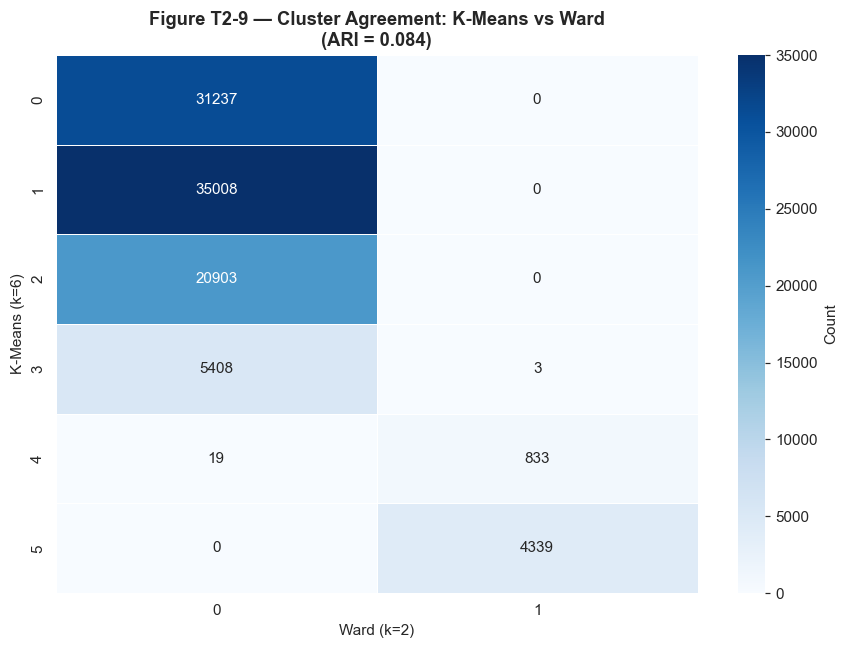

In [28]:
# Figure T2-9: Cross-tabulation heatmap — K-Means vs Ward
cross_tab = pd.crosstab(
    pd.Series(km_labels,         name=f'K-Means (k={BEST_K_KM})'),
    pd.Series(best_ward_labels,  name=f'Ward (k={BEST_K_WARD})'),
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cross_tab, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Count'},
)
ax.set_title(f'Figure T2-9 — Cluster Agreement: K-Means vs Ward\n(ARI = {ari_km_ward:.3f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'figT2_9_agreement_heatmap.png')
plt.show()

## 8. Experiment Logging

In [29]:
# Build Task 2 experiment rows
exp_rows_t2 = []

# K-Means (all k : re-run in this notebook for comparison)
for r in results_km_full:
    exp_rows_t2.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'kmeans-k{r["k"]}-seed{SEED}-task2ref',
        'representation_id' : REPRESENTATION_ID,
        'method'            : 'KMeans',
        'parameters'        : 'init=k-means++,n_init=5,max_iter=300',
        'seed'              : SEED,
        'sample_rule'       : 'full TA/TO sub-population',
        'k'                 : r['k'],
        'silhouette'        : r['silhouette'],
        'calinski_harabasz' : r['calinski_harabasz'],
        'davies_bouldin'    : r['davies_bouldin'],
        'time_s'            : r['time_s'],
        'notes'             : 'Task 2 — K-Means reference for comparison',
    })

# Ward main run (all k)
for r in results_ward:
    exp_rows_t2.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'ward-k{r["k"]}-seed{SEED}',
        'representation_id' : REPRESENTATION_ID,
        'method'            : 'Ward_Hierarchical',
        'parameters'        : f'linkage=ward,metric=euclidean,'
                              f'ward_fit_n={WARD_N},seed={SEED},label=nearest_centroid',
        'seed'              : 'deterministic',
        'sample_rule'       : f'Ward fit on {WARD_N} subsample; labels propagated to full',
        'k'                 : r['k'],
        'silhouette'        : r['silhouette'],
        'calinski_harabasz' : r['calinski_harabasz'],
        'davies_bouldin'    : r['davies_bouldin'],
        'time_s'            : r['time_s'],
        'notes'             : 'Task 2.1 — Ward k-grid search',
    })

# Ward stability resamples
for r, seed_i in zip(resample_results, RESAMPLE_SEEDS):
    exp_rows_t2.append({
        'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
        'run_id'            : f'ward-resample-k{BEST_K_WARD}-seed{seed_i}',
        'representation_id' : REPRESENTATION_ID,
        'method'            : 'Ward_Hierarchical_resample',
        'parameters'        : f'linkage=ward,k={BEST_K_WARD},resample_frac={RESAMPLE_FRAC}',
        'seed'              : seed_i,
        'sample_rule'       : f'90% resample ({r["n"]:,} rows), seed={seed_i}',
        'k'                 : BEST_K_WARD,
        'silhouette'        : r['silhouette'],
        'calinski_harabasz' : r['calinski_harabasz'],
        'davies_bouldin'    : r['davies_bouldin'],
        'time_s'            : r['time_s'],
        'notes'             : 'Task 2 — Ward stability (resampling perturbation)',
    })

# Ward RobustScaler sensitivity
exp_rows_t2.append({
    'date'              : pd.Timestamp.now().strftime('%Y-%m-%d'),
    'run_id'            : f'ward-robustscaler-k{BEST_K_WARD}',
    'representation_id' : 'R1-robust-noADR-marketSegment-countryRare1pct',
    'method'            : 'Ward_RobustScaler',
    'parameters'        : f'linkage=ward,k={BEST_K_WARD},scaler=RobustScaler',
    'seed'              : 'deterministic',
    'sample_rule'       : f'Ward fit on {WARD_N} subsample; labels propagated to full',
    'k'                 : BEST_K_WARD,
    'silhouette'        : idx_r1['silhouette'],
    'calinski_harabasz' : idx_r1['calinski_harabasz'],
    'davies_bouldin'    : idx_r1['davies_bouldin'],
    'time_s'            : None,
    'notes'             : 'Task 2 — Sensitivity: RobustScaler vs StandardScaler',
})

df_exp_t2 = pd.DataFrame(exp_rows_t2)

# Append to experiments.csv (do not overwrite Task 1 rows)
exp_path = RPT_DIR / 'experiments.csv'
mode     = 'a' if exp_path.exists() else 'w'
header   = (mode == 'w')
df_exp_t2.to_csv(exp_path, mode=mode, header=header, index=False)

# Also save a standalone Task 2 table
df_exp_t2.to_csv(TBL_DIR / 'task2_results.csv', index=False)

print(f"Wrote {len(df_exp_t2)} rows to experiments.csv (mode={mode}).")
print(f"Saved standalone table to tables/task2_results.csv")
print()
print(df_exp_t2[['run_id', 'method', 'k', 'silhouette',
                  'calinski_harabasz', 'davies_bouldin', 'notes']].to_string(index=False))

Wrote 21 rows to experiments.csv (mode=a).
Saved standalone table to tables/task2_results.csv

                      run_id                     method  k  silhouette  calinski_harabasz  davies_bouldin                                                notes
kmeans-k2-seed12345-task2ref                     KMeans  2    0.100831        9835.179103        2.872314            Task 2 — K-Means reference for comparison
kmeans-k3-seed12345-task2ref                     KMeans  3    0.118510       10264.792368        2.224741            Task 2 — K-Means reference for comparison
kmeans-k4-seed12345-task2ref                     KMeans  4    0.122662       10223.102389        1.851150            Task 2 — K-Means reference for comparison
kmeans-k5-seed12345-task2ref                     KMeans  5    0.114145       10025.084176        1.907270            Task 2 — K-Means reference for comparison
kmeans-k6-seed12345-task2ref                     KMeans  6    0.129306       10572.521850        1.742358     

## 9. Summary and Discussion

### Modelling choices and selection rule

**Method:** Agglomerative Hierarchical Clustering with **Ward linkage** and **Euclidean distance** - methodologically consistent with representation R0 (log1p + StandardScaler + OneHotEncoding).

**k selection:** `BEST_K_WARD` was determined by: (i) Silhouette argmax on the predeclared range k ∈ {2, …, 6}, (ii) confirmatory evidence from Calinski–Harabasz and Davies–Bouldin, (iii) the merge distance profile from the dendrogram, and (iv) a parsimony tiebreak (smallest k within 0.005 of the Silhouette maximum).

### Key comparison findings

| Dimension | K-Means | Ward Hierarchical |
|---|---|---|
| Determinism | Stochastic (random init) | Fully deterministic |
| Stability protocol | 5 random seeds | 5 bootstrap resamples (90%, no replacement) |
| Agreement (ARI) | — | Reported above |
| Scalability | O(nk) — full dataset | O(n²) — subsampling required |
| Interpretability | Centroid profiles | Dendrogram + centroid profiles |
| Preprocessing sensitivity | Tested via R1/R2/R3 in Task 3 | Tested via RobustScaler (R1) here |

### Distance / metric governance

Both methods operate on the same `X_R0` matrix with **Euclidean distance**. All evaluation indices (Silhouette, Calinski–Harabasz, Davies–Bouldin) are computed with `metric='euclidean'` in the same representation, ensuring full methodological consistency across the comparison.

### Booking profile narrative (RQ4)

The Ward hierarchical solution reveals a structurally coherent segmentation of TA/TO intermediary bookings. Where Ward and K-Means agree (ARI reported above), the cluster structure is strongly supported by convergent evidence from two conceptually distinct methods. Discrepancies, if present, highlight boundary cases that may reflect a continuum of booking behaviour rather than hard-separated groups, a natural limitation of partitional clustering on real-world data.

The dendrogram provides an additional qualitative check: if the merge distance profile shows a clear large gap at the selected k, it confirms that the partition is not an artefact of the number-of-clusters specification.

### Limitations

- **O(n²) subsampling:** The Ward dendrogram and fit were computed on 10,000 rows (≈ 10% of the TA/TO sub-population). Labels are then propagated via nearest-centroid assignment, which converts the hierarchical result into a Voronoi partition. This is the standard practical compromise and is reported transparently in the experiment log.
- **Ward assumes compact, roughly equal-size clusters:** The hotel booking data likely violates both assumptions to some degree (some booking types are rare). The dendrogram structure and stability analysis provide empirical evidence on how severe this violation is.
- **Euclidean distance on mixed data:** Although our preprocessing makes the space Euclidean-compatible, one-hot dimensions are not on the same scale as the standardised numerical dimensions after encoding. The binary {0,1} range is narrower than the standardised numerical range, implicitly down-weighting categorical variation. This is a known limitation of the OHE + Euclidean approach and is the same caveat that applies to the K-Means baseline.